# EDA — dataset de Fase 1 (CPU y GPU)

Exploración inicial sobre el dataset ya cerrado de Fase 1: distribución de
etiquetas de fase (`compute_bound`/`memory_bound`) y matrices de
correlación entre las señales de telemetría, por separado para CPU y GPU.

Carga los datos vía `classifier.features.load` — el mismo módulo que
usará el pipeline de entrenamiento, para no duplicar la lógica de
filtrado entre el notebook y los scripts de `training/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.home() / "hyperion"))
from classifier.features import load

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Dataset de CPU

In [2]:
CPU_CAMPAIGN_DIR = Path.home() / "hyperion-results/campaigns/pacca_cpu_final_attempt03_20260820_arc174"
CPU_CAMPAIGN_ID = "pacca_cpu_final_attempt03_20260820"
CPU_KERNELS = [
    "npb_bt", "npb_mg", "npb_cg", "npb_sp", "npb_ft", "npb_lu",
    "dgemm_n2048", "rodinia_lavamd_omp", "rajaperf_polybench_3mm_omp",
]
CPU_LEVELS = ["REF", "F0", "F1", "F2", "F3", "F4"]

cpu_raw = load.load_run_matrix(
    CPU_CAMPAIGN_DIR,
    "{campaign_id}__{kernel}__{level}__rep{rep:02d}",
    campaign_id=[CPU_CAMPAIGN_ID], kernel=CPU_KERNELS, level=CPU_LEVELS, rep=range(1, 11),
)
cpu = load.filter_cpu_trainable(cpu_raw)
print(f"{len(cpu_raw):,} ventanas totales -> {len(cpu):,} entrenables ({len(cpu)/len(cpu_raw):.1%})")

10,251,941 ventanas totales -> 9,953,976 entrenables (97.1%)


### 1.1 Distribución de etiquetas de fase (CPU)

phase_label_train
memory_bound     4995454
compute_bound    4958522
Name: count, dtype: int64

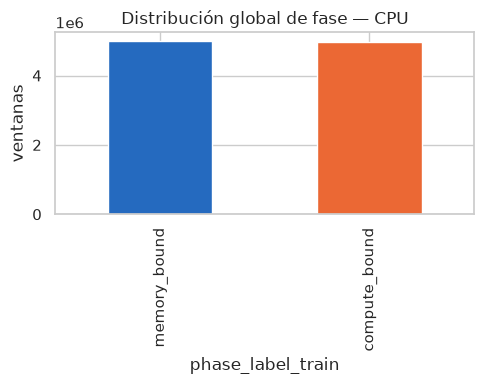

In [3]:
label_counts = cpu["phase_label_train"].value_counts()
display(label_counts)

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.plot.bar(ax=ax, color=["#256abf", "#eb6834"])
ax.set_ylabel("ventanas")
ax.set_title("Distribución global de fase — CPU")
plt.tight_layout()

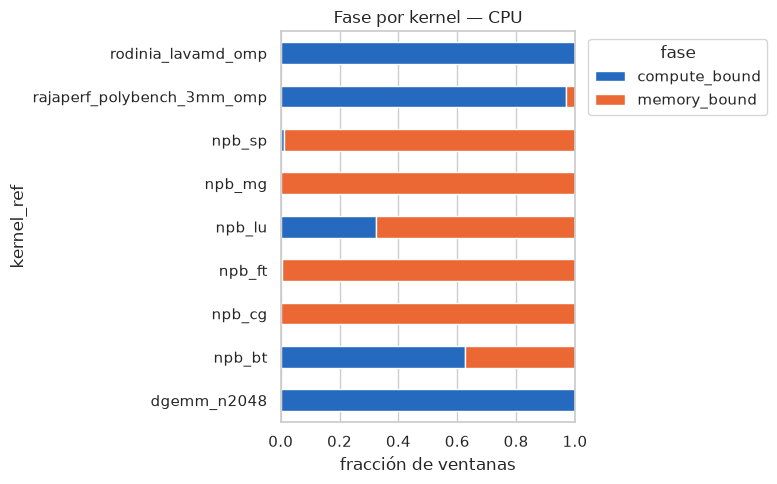

In [4]:
# Distribución por kernel -- si algún kernel queda casi puro en una sola
# fase, el modelo no tiene contraste real para ese kernel específico.
by_kernel = pd.crosstab(cpu["kernel_ref"], cpu["phase_label_train"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 5))
by_kernel.plot.barh(stacked=True, ax=ax, color=["#256abf", "#eb6834"])
ax.set_xlabel("fracción de ventanas")
ax.set_title("Fase por kernel — CPU")
ax.legend(title="fase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

### 1.2 Matriz de correlación (CPU)

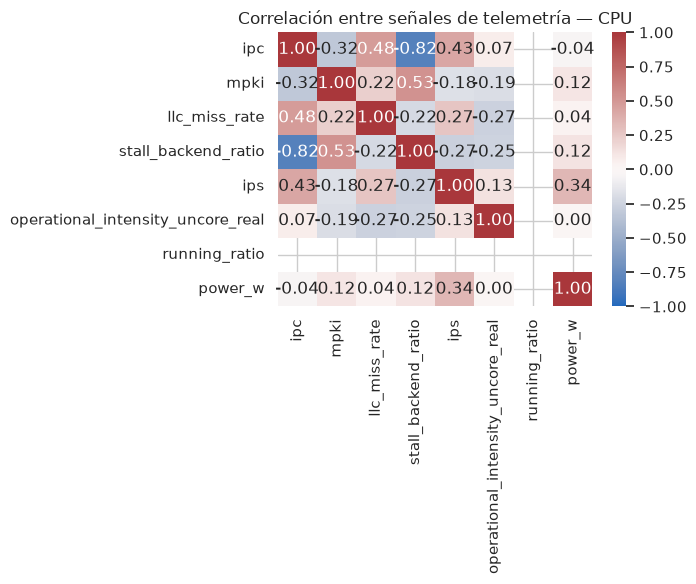

In [5]:
CPU_NUMERIC_FEATURES = [
    "ipc", "mpki", "llc_miss_rate", "stall_backend_ratio", "ips",
    "operational_intensity_uncore_real", "running_ratio", "power_w",
]
cpu_corr = cpu[CPU_NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cpu_corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre señales de telemetría — CPU")
plt.tight_layout()

## 2. Dataset de GPU

Las filas de telemetría de GPU son *passthrough* (ARC-70): no traen las
columnas de PMU de CPU (`ipc`, `mpki`, etc. quedan vacías), así que la
matriz de correlación usa únicamente las señales propias de GPU +
intensidad operacional.

In [6]:
GPU_CAMPAIGN_DIR = Path.home() / "hyperion-results/campaigns/pacca_gpu_dvfs_20260820"
GPU_CAMPAIGN_ID = "pacca_gpu_dvfs_20260820"
GPU_KERNELS = [
    "gpu_dgemm_n4096", "rodinia_gaussian", "rodinia_backprop", "rodinia_lavamd",
    "rodinia_heartwall", "rodinia_lud", "rodinia_myocyte", "rodinia_dwt2d",
]
GPU_CPU_LEVELS = ["REF", "F4"]
GPU_LEVELS = ["REF", "F0", "F1", "F2", "F3", "F4"]

gpu_raw = load.load_run_matrix(
    GPU_CAMPAIGN_DIR,
    "{campaign_id}__{kernel}__{cpu_level}__gpu{gpu_level}__rep{rep:02d}",
    campaign_id=[GPU_CAMPAIGN_ID], kernel=GPU_KERNELS, cpu_level=GPU_CPU_LEVELS,
    gpu_level=GPU_LEVELS, rep=range(1, 4),
)
gpu = load.filter_gpu_trainable(gpu_raw)
print(f"{len(gpu_raw):,} ventanas totales -> {len(gpu):,} entrenables ({len(gpu)/len(gpu_raw):.1%})")

/home/latorresn/hyperion/classifier/features/load.py:65: DtypeWarning: Columns (0: phase_label_uncore_real) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(windows_path))


2,171,803 ventanas totales -> 160,142 entrenables (7.4%)


### 2.1 Distribución de etiquetas de fase (GPU)

phase_label_train
compute_bound    84259
memory_bound     75883
Name: count, dtype: int64

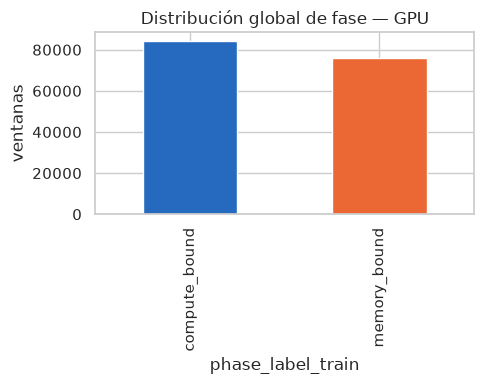

In [7]:
gpu_label_counts = gpu["phase_label_train"].value_counts()
display(gpu_label_counts)

fig, ax = plt.subplots(figsize=(5, 4))
gpu_label_counts.plot.bar(ax=ax, color=["#256abf", "#eb6834"])
ax.set_ylabel("ventanas")
ax.set_title("Distribución global de fase — GPU")
plt.tight_layout()

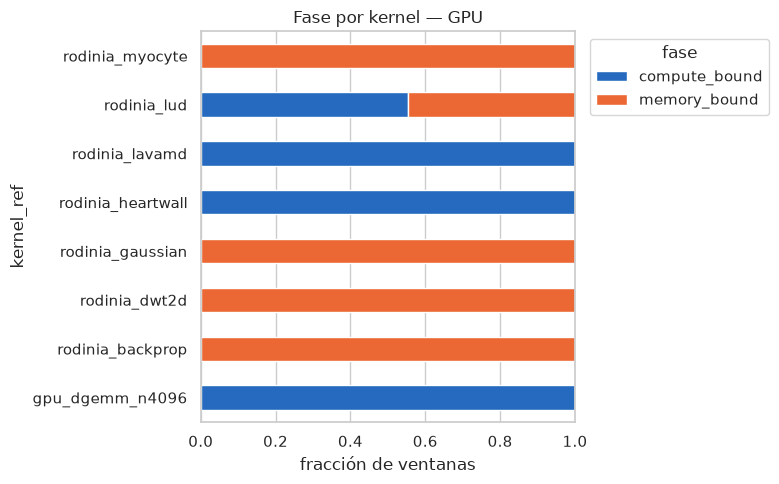

In [8]:
by_kernel_gpu = pd.crosstab(gpu["kernel_ref"], gpu["phase_label_train"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 5))
by_kernel_gpu.plot.barh(stacked=True, ax=ax, color=["#256abf", "#eb6834"])
ax.set_xlabel("fracción de ventanas")
ax.set_title("Fase por kernel — GPU")
ax.legend(title="fase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

### 2.2 Matriz de correlación (GPU)

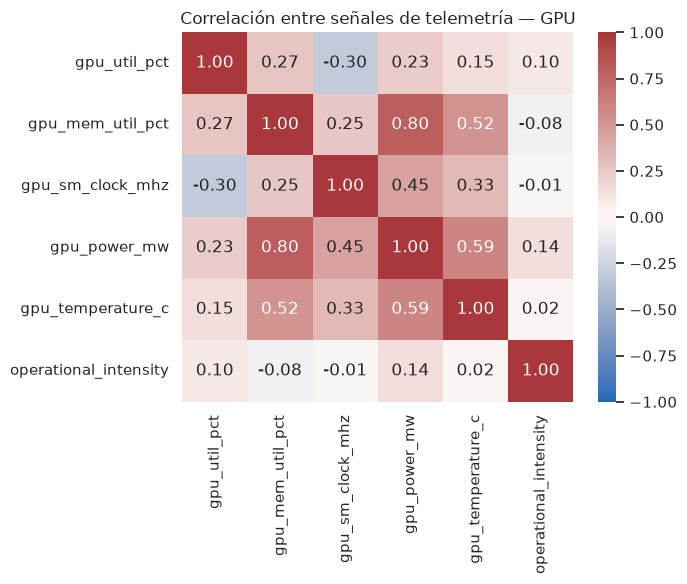

In [9]:
GPU_NUMERIC_FEATURES = [
    "gpu_util_pct", "gpu_mem_util_pct", "gpu_sm_clock_mhz",
    "gpu_power_mw", "gpu_temperature_c", "operational_intensity",
]
gpu_corr = gpu[GPU_NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(gpu_corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre señales de telemetría — GPU")
plt.tight_layout()

## 3. Notas / próximos pasos

_(completar tras revisar los resultados de arriba)_